# Product-level LCA: RAW case vs. baseline products

Pick a product spec (beam span / wall length / membrane coverage). The model then

1. translates the spec into material amounts with the product-LCI formulas (`product_lci.csv`, from the Google Sheet),
2. runs each RAW case (BOM, process chain, repair and end of life from the `raw_*` tabs of the sheet), a scaled-up variant of it, and the baseline product(s) flagged for it in the sheet (`comparison_raw_*`), for the same spec,
3. shows burdens, benefits and net impact per impact category, today vs. 2050, and how the result changes with product size.

| layer | file |
|---|---|
| base data: unit burdens / benefits / EoL constants | `data/processed/unit_burdens.csv`, `benefits_constants.csv`, `eol_constants.csv` (from `01_dataPrep`, `01b_dataPrep_prospective`) |
| product LCI: spec -> amounts | `data/processed/product_lci.csv`, `baseline_eol.csv` (from `01c_dataPrep_productLCI`) |
| RAW case definitions (BOM, process chain, repair, end of life) | `data/processed/raw_*.csv` (from the `raw_*` tabs of the sheet via `01c_dataPrep_productLCI`), loaded by `cases.py` |
| model functions | `lca_engine.py` (same formulas as `02_model.ipynb`) |

## 1. Choose the product specs

In [1]:
# ── The only cell you need to edit ────────────────────────────────────────────
# Product specs - each RAW case uses the one that belongs to it
SPECS = {
    "span": 6.0,        # m   - beam span            (raw_timber, raw_cfw)
    "length": 4.0,      # m   - wall length          (raw_biopol; wall height is 3 m in the sheet)
    "coverage": 100.0,  # m2  - membrane coverage    (raw_knit)
}

RAW_CASE = "raw_timber"     # case used for the spec sweep and the two tables below
                            # "raw_biopol" | "raw_timber" | "raw_cfw" | "raw_knit"

SCENARIO = "baseline"                # background of the 'today' rows / the sweep
SCENARIO_2050 = "image_SSP2-L_2050"  # background of the '2050' rows


In [2]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from lca_engine import DataStore, activity_amounts, baselines_for, compare, spec_variable, GWP
from cases import load_raw_cases, scaled_up_variants, compare_chains

DATA_DIR = "../../data/processed"
RAW_CASES = load_raw_cases(DATA_DIR)      # RAW case definitions come from the raw_* tabs of the Google Sheet

def make_datastore(scenario):
    d = DataStore(DATA_DIR, scenario)
    # Baselines come from the sheet's comparison_raw_* flags. To compare a RAW case with an extra
    # baseline product, add its product-LCI case_name here (it must have burden data in unit_burdens.csv).
    d.extra_baselines = {"raw_cfw": ["glulam beam"]}
    # Each RAW case is also run in a 'scaled up' variant: production machines from the sheet's large-scale column.
    # Set to {} to drop the scaled-up bars.
    d.raw_variants = scaled_up_variants(RAW_CASES, d)
    return d

ds = make_datastore(SCENARIO)
ds_2050 = make_datastore(SCENARIO_2050)

if RAW_CASE not in RAW_CASES:
    raise ValueError(f"Unknown RAW_CASE '{RAW_CASE}' - choose one of {list(RAW_CASES)}")
case = RAW_CASES[RAW_CASE]
spec_row = ds.product_lci[ds.product_lci["case_name"] == RAW_CASE].iloc[0]
spec_value = SPECS[spec_variable(ds, RAW_CASE)]
print(f"{case.name}: {spec_row.spec_label} = {spec_value} {spec_row.spec_unit}")
print(f"Baselines: {baselines_for(ds, RAW_CASE)}")

# pre-flight: every (material, source, location) of every RAW case must have burden data in both backgrounds
for d, name in ((ds, SCENARIO), (ds_2050, SCENARIO_2050)):
    for cid, c in RAW_CASES.items():
        for m in d.missing_burdens(c):
            print(f"MISSING DATA ({name}, {cid}): {m}")


RAW reclaimed timber (CNC beam): beam span = 6.0 m
Baselines: ['glulam beam', 'reinforced concrete beam']


### RAW case vs. scaled-up variant (production chain)

The scaled-up variant is defined entirely by the Google Sheet tab `processes_typicalValues` (via `machine_params.csv`, written by `01c_dataPrep_productLCI`): a production step whose name is a `machining process` on that tab takes the machine's **large-scale** weight, lifetime, output rate and power. All other steps, the repair chain, BOM, lifetimes and end of life are unchanged. No other scaling rules exist in the repo.

In [3]:
display(compare_chains(RAW_CASES, RAW_CASE, ds))

,step,source of scaled-up values,machine kg,power kW,output kg/hr,lifetime hrs
0,Scanning,unchanged (no machine of this name on the sheet),2000 -> 2000,10 -> 10,600 -> 600,40000 -> 40000
1,CNC milling,sheet: processes_typicalValues (large scale),1200 -> 5000,10 -> 20,30 -> 10,40000 -> 70000


### Spec -> amounts (product LCI)

In [4]:
rows = []
for name in [RAW_CASE] + baselines_for(ds, RAW_CASE):
    a = activity_amounts(ds, name, spec_value)
    a.insert(0, "case", name)
    rows.append(a)
amounts = pd.concat(rows, ignore_index=True)
amounts["amount"] = amounts["amount"].map(lambda v: float(f"{v:.5g}"))
display(amounts[["case", "activity_name", "amount", "activity_unit", "formula"]])

,case,activity_name,amount,activity_unit,formula
0,raw_timber,raw_timber production,86.40,kg,span * (span/20) * ((span/20)/3) * 480
1,glulam beam,glulam timber,0.18,m3,(span / 20) * ((span / 20) / 3) * span
2,reinforced concrete beam,concrete,1692.00,kg,span * (span / 12) * (0.5 * (span / 12)) * 240...
3,reinforced concrete beam,steel,108.00,kg,(span * (span / 12) * (0.5 * (span / 12)) * 24...
4,reinforced concrete beam,formwork,8.10,kg,span * (2 * (span/12) + (0.5*span/12)) * 0.018...


## 2. Today vs. 2050: burdens, benefits and net impact per category

One chart per RAW case, each compared with its own baselines at its own spec from `SPECS` (timber and CFW: span; biopol: wall length; knit: membrane coverage). Each impact category appears twice: first with today's background (`SCENARIO`), then with the 2050 background (`SCENARIO_2050`).

- **Solid bar (right)**: burdens (materials, production, repair, end-of-life treatment).
- **Light bar (left)**: benefits (carbon storage and circularity credits; carbon storage only exists for climate change).
- **Dot**: net impact = burdens + benefits.
- Both rows of a category share one scale: 100 % = the largest burden or benefit of any case in either row, so today and 2050 can be compared directly.
- Bars have the same thickness in every chart; the figure height grows with the number of cases compared.
- **Colours**: RAW cases green, scaled-up RAW cases blue, conventional bio-based orange, conventional fossil-based grey.

In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CHART_CATEGORIES = ["climate change", "ozone depletion", "particulate matter formation", "acidification",
                    "eutrophication: freshwater", "land use", "water use", "material resources: metals/minerals"]
CATEGORY_LABELS = {"eutrophication: freshwater": "freshwater eutrophication",
                   "material resources: metals/minerals": "mineral resources"}

TYPE_COLORS = {"raw": "#3B8C6E", "raw scaled up": "#3FA9F5",
               "conventional bio-based": "#E08A2E", "conventional fossil-based": "#8C8C8C"}
TYPE_LABELS = {"raw": "RAW case", "raw scaled up": "RAW case, scaled up", "conventional bio-based": "conventional, bio-based",
               "conventional fossil-based": "conventional, fossil-based"}
_case_type = ds.product_lci.drop_duplicates("case_name").set_index("case_name")["case_type"].to_dict()

def type_of(label):
    if label.startswith("RAW"):
        return "raw scaled up" if "scaled up" in label else "raw"
    return _case_type.get(label, "conventional fossil-based")

def color_for(label):
    return TYPE_COLORS[type_of(label)]


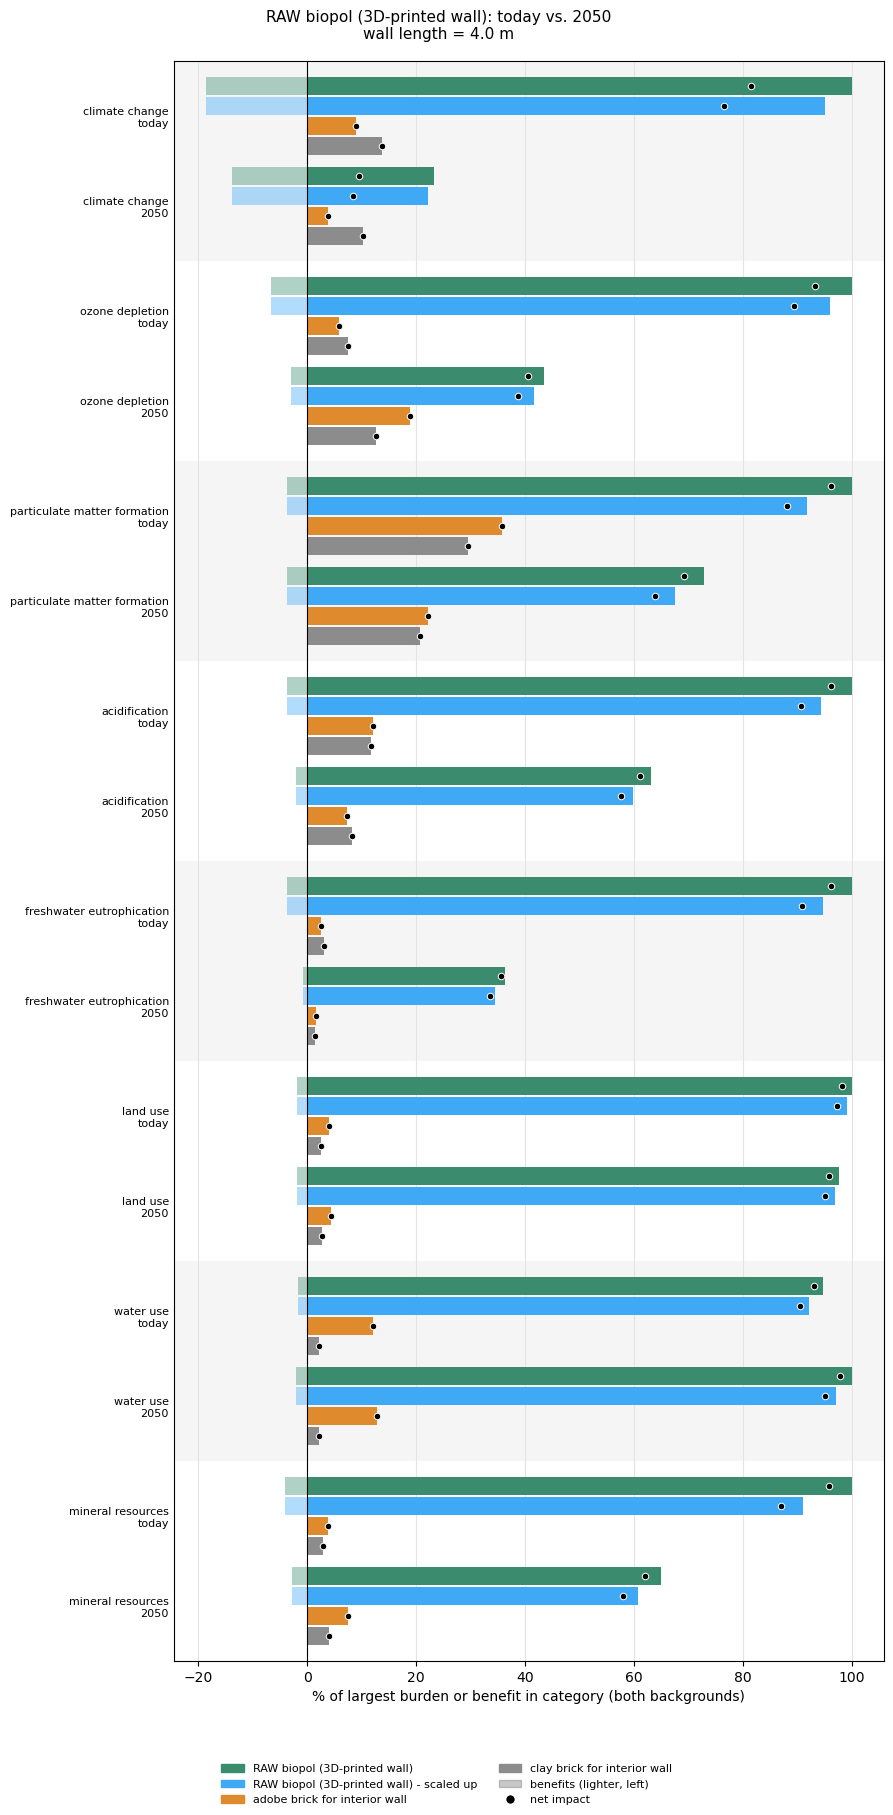

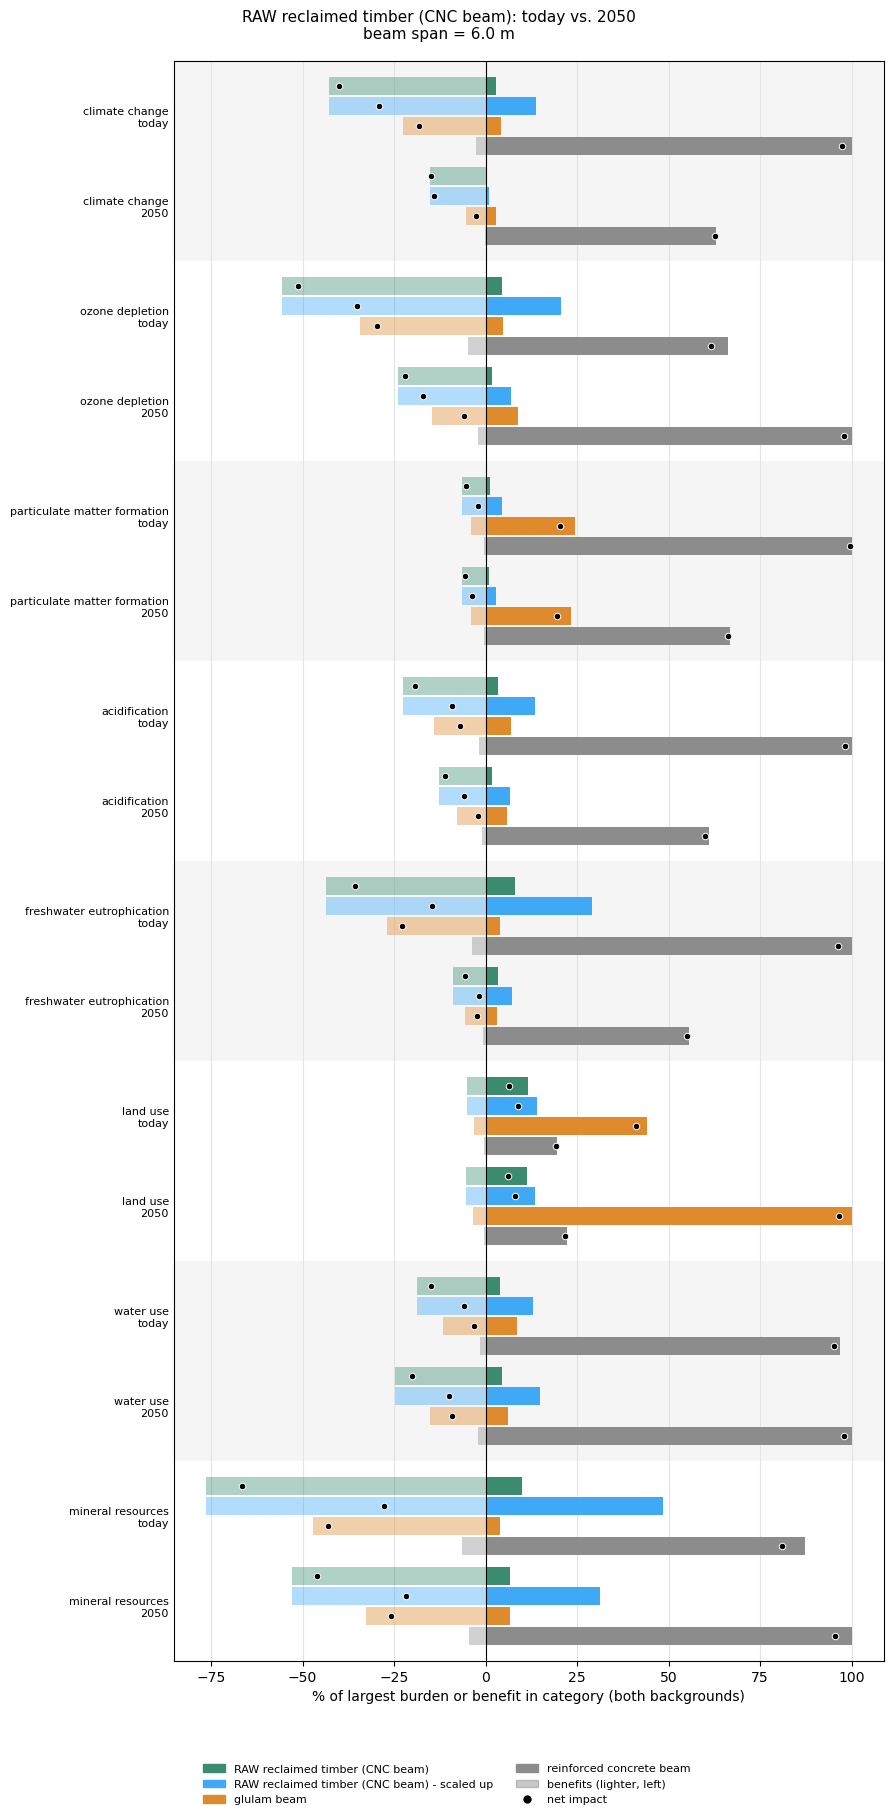

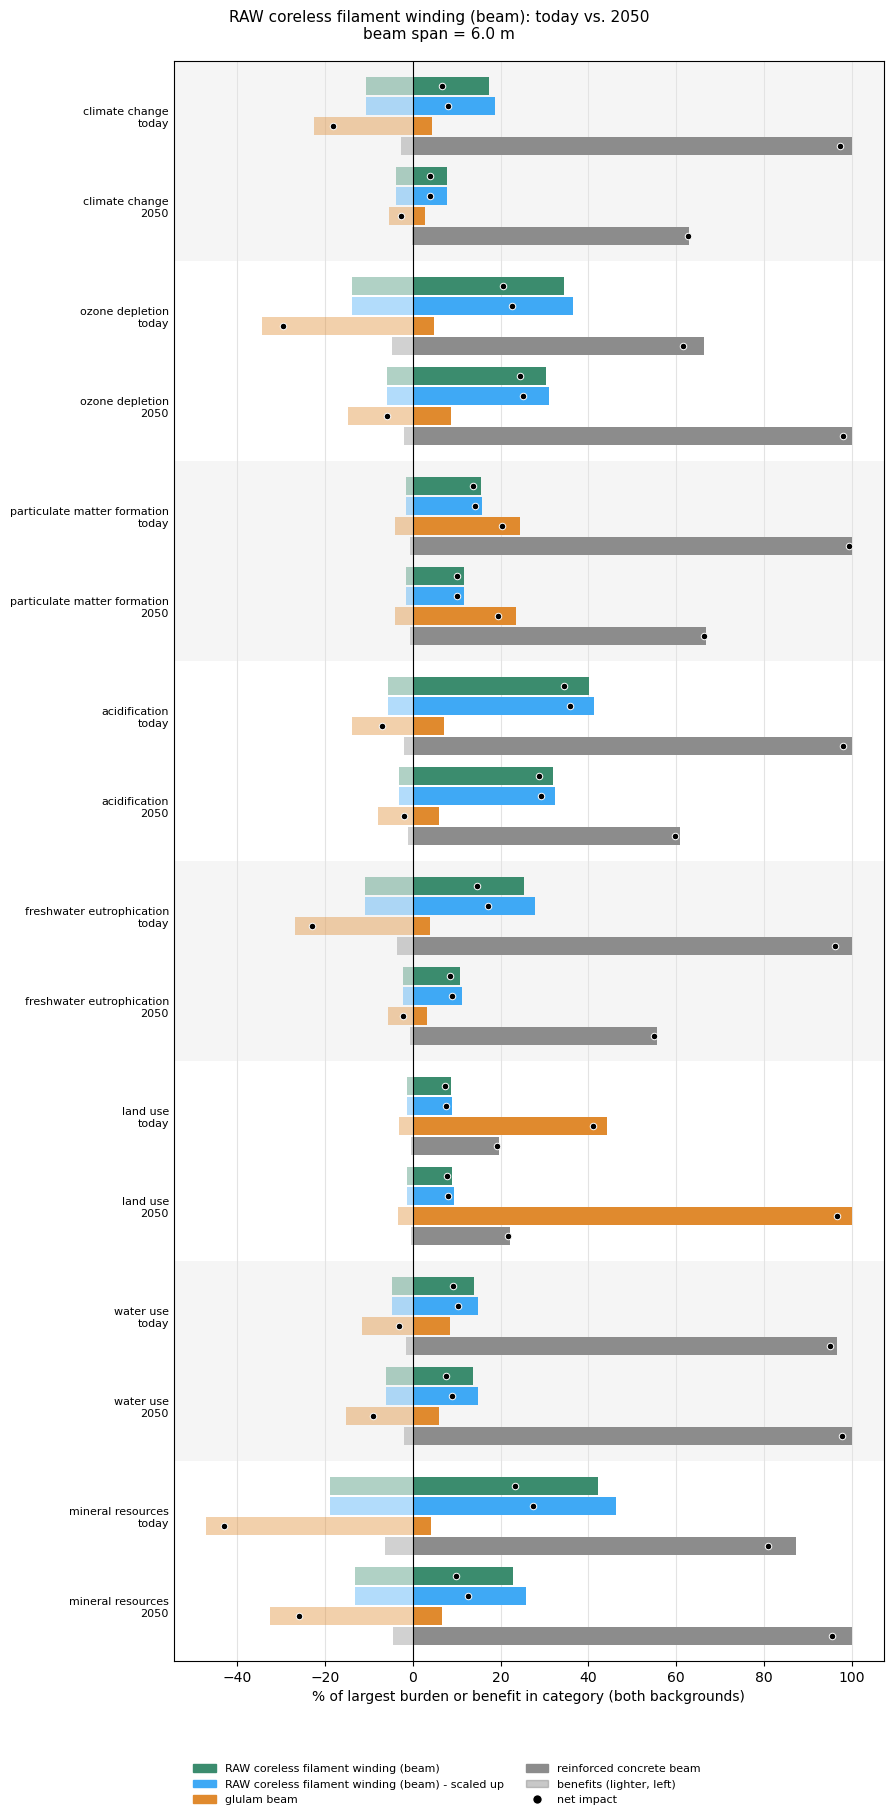

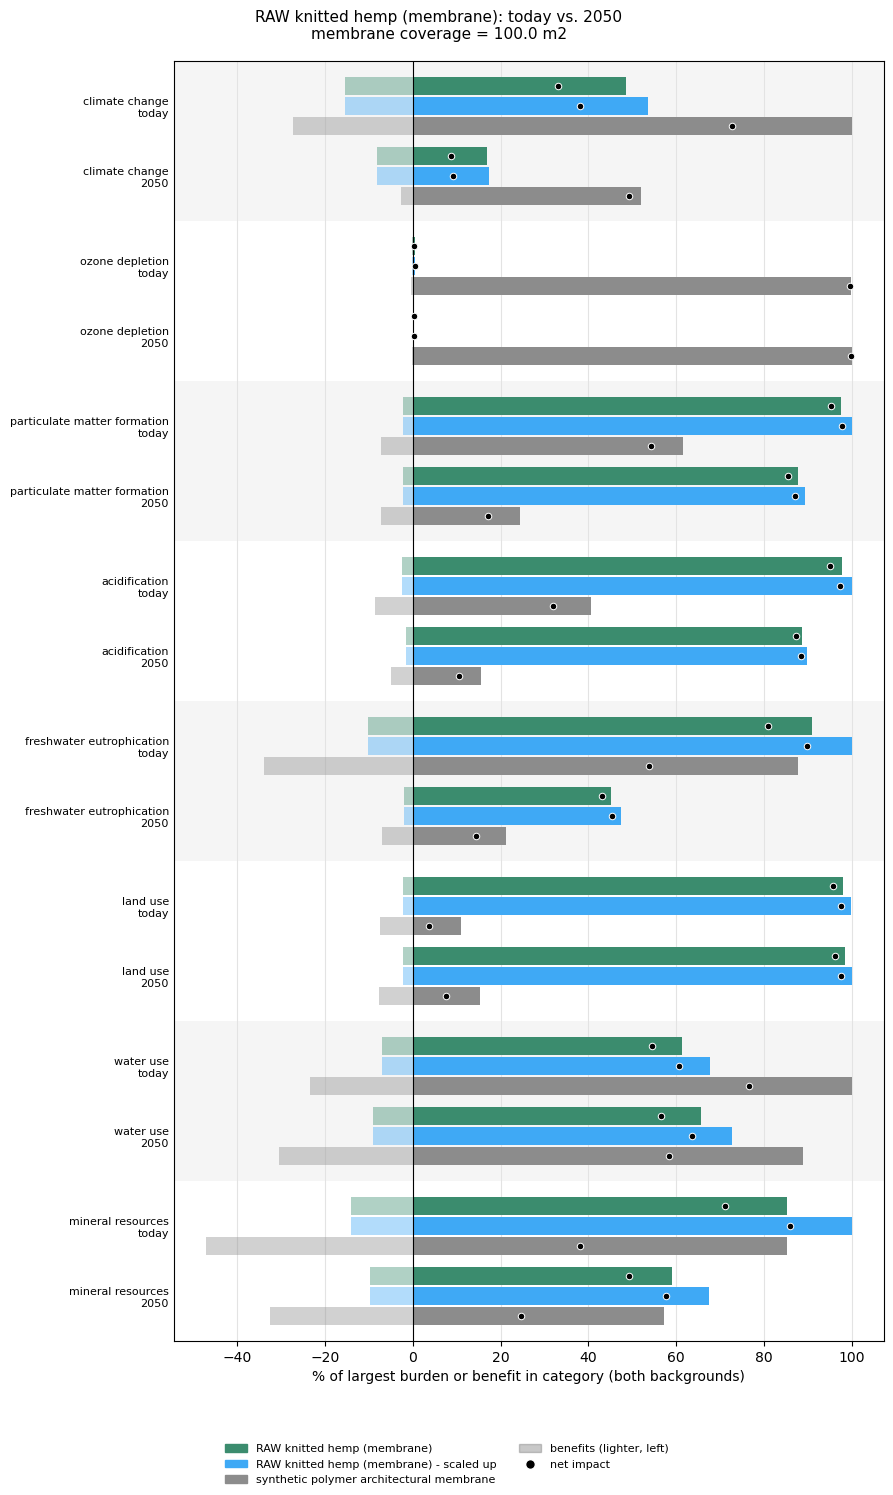

In [6]:
def plot_combined_chart(raw_case_id, ds_a, label_a, ds_b, label_b, unit_in=0.2):
    # unit_in = inches per bar row: every bar has the same thickness, chart height follows the number of bars
    var = spec_variable(ds_a, raw_case_id)
    row = ds_a.product_lci[ds_a.product_lci["case_name"] == raw_case_id].iloc[0]
    res_a = compare(ds_a, RAW_CASES, raw_case_id, SPECS[var])
    res_b = compare(ds_b, RAW_CASES, raw_case_id, SPECS[var])
    labels = list(res_a)
    n = len(labels)

    def tables(res):
        f = lambda attr: pd.DataFrame({l: getattr(r, attr) for l, r in res.items()}).reindex(CHART_CATEGORIES)
        return f("burdens"), f("benefits"), f("net")
    tab = {label_a: tables(res_a), label_b: tables(res_b)}
    scale = pd.concat([t.abs() for tabs in tab.values() for t in tabs[:2]]).groupby(level=0).max() \
        .max(axis=1).reindex(CHART_CATEGORIES)

    # vertical layout in bar-row units
    GAP_WITHIN, GAP_BETWEEN = 0.5, 1.5
    starts, y0 = [], 0.0
    for _ in CHART_CATEGORIES:
        a = y0; b = a + n + GAP_WITHIN
        starts.append((a, b)); y0 = b + n + GAP_BETWEEN
    ymin, ymax = -GAP_BETWEEN / 2, y0 - GAP_BETWEEN / 2

    w, left, right, top, bottom = 9.5, 2.1, 0.3, 0.75, 1.5
    axes_h = (ymax - ymin) * unit_in
    fig = plt.figure(figsize=(w, axes_h + top + bottom))
    ax = fig.add_axes([left / w, bottom / (axes_h + top + bottom), (w - left - right) / w, axes_h / (axes_h + top + bottom)])

    yticks, ytick_labels = [], []
    for ci, (cat, (ya, yb)) in enumerate(zip(CHART_CATEGORIES, starts)):
        if ci % 2 == 0:
            ax.axhspan(ya - GAP_BETWEEN / 2, yb + n + GAP_BETWEEN / 2, color="#F5F5F5", zorder=0, linewidth=0)
        for (y_start, lab) in ((ya, label_a), (yb, label_b)):
            burden, benefit, net = tab[lab]
            for i, l in enumerate(labels):
                yi = y_start + i + 0.5
                c = color_for(l)
                ax.barh(yi, burden.loc[cat, l] / scale[cat] * 100, height=0.9, color=c, zorder=2)
                ax.barh(yi, benefit.loc[cat, l] / scale[cat] * 100, height=0.9, color=c, alpha=0.4, zorder=2)
                ax.scatter(net.loc[cat, l] / scale[cat] * 100, yi, s=22, color="black", edgecolor="white", linewidth=0.7, zorder=4)
            yticks.append(y_start + n / 2)
            ytick_labels.append(f"{CATEGORY_LABELS.get(cat, cat)}\n{lab}")
    ax.axvline(0, color="black", linewidth=0.8, zorder=3)
    ax.set_axisbelow(True); ax.grid(axis="x", color="#E3E3E3", linewidth=0.8)
    ax.set_ylim(ymax, ymin)                       # first category on top
    ax.set_yticks(yticks); ax.set_yticklabels(ytick_labels, fontsize=8)
    ax.tick_params(axis="y", length=0)
    ax.set_xlabel("% of largest burden or benefit in category (both backgrounds)")
    fig.suptitle(f"{RAW_CASES[raw_case_id].name}: today vs. 2050\n"
                 f"{row.spec_label} = {SPECS[var]} {row.spec_unit}", fontsize=11, y=1 - 0.08 / (axes_h + top + bottom) * 3)
    handles = [Patch(color=color_for(l), label=l) for l in labels]
    handles += [Patch(color="#777777", alpha=0.4, label="benefits (lighter, left)"),
                Line2D([0], [0], marker="o", color="none", markerfacecolor="black", markeredgecolor="white",
                       markersize=7, label="net impact")]
    fig.legend(handles=handles, frameon=False, loc="lower center", ncol=2, fontsize=8)
    plt.show()

label_today = "today" if SCENARIO == "baseline" else SCENARIO
for raw_case_id in RAW_CASES:
    plot_combined_chart(raw_case_id, ds, label_today, ds_2050, "2050")

## 4. Spec sweep

The product-LCI formulas are non-linear in the spec (e.g. glulam volume grows with span^3), so which product wins can depend on the size. This re-runs the comparison for `RAW_CASE` over a range of spec values (`SCENARIO` background), for climate change. The dotted line marks the spec chosen in `SPECS`.

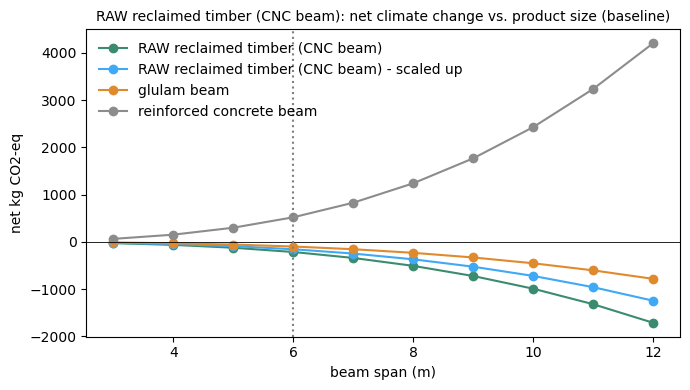

In [7]:
SWEEP = {"span": np.linspace(3, 12, 10), "length": np.linspace(2, 12, 11), "coverage": np.linspace(10, 500, 10)}[spec_variable(ds, RAW_CASE)]

sweep = {}
for v in SWEEP:
    res = compare(ds, RAW_CASES, RAW_CASE, float(v))
    for l, r in res.items():
        sweep.setdefault(l, []).append(r.net[GWP])
fig, ax = plt.subplots(figsize=(7, 4))
for l, ys in sweep.items():
    ax.plot(SWEEP, ys, marker="o", color=color_for(l), label=l)
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(spec_value, color="grey", linestyle=":")
ax.set_xlabel(f"{spec_row.spec_label} ({spec_row.spec_unit})"); ax.set_ylabel("net kg CO2-eq")
ax.set_title(f"{case.name}: net climate change vs. product size ({SCENARIO})", fontsize=10); ax.legend(frameon=False)
plt.tight_layout(); plt.show()